In [17]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

In [18]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

In [19]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

In [20]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

PROJECT_DIR = Path("/workspace/gps-spoofing")
FEATURES_DIR = PROJECT_DIR / "features"
REPORTS_DIR = PROJECT_DIR / "reports"
MODELS_DIR = PROJECT_DIR / "models"

REPORTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

parquet_files = sorted(FEATURES_DIR.glob("*.parquet"))

print("Parquet files:", len(parquet_files))
for p in parquet_files:
    print(p.name)


def get_scenario_key(filename: str) -> str:
    name = filename.upper()

    m = re.search(r"(SS\d+)", name)
    if m:
        return m.group(1)

    m = re.search(r"(C\d+)", name)
    if m:
        return m.group(1)

    return "UNKNOWN"


dfs = []

for p in parquet_files:
    df = pd.read_parquet(p).copy()

    scenario = get_scenario_key(p.name)

    df["source_file"] = p.name
    df["scenario"] = scenario

    dfs.append(df)

assert len(dfs) > 0, f"Nie znaleziono plików .parquet w {FEATURES_DIR}"

all_df = pd.concat(dfs, ignore_index=True)

print("all_df shape:", all_df.shape)
display(all_df.head())
display(all_df["scenario"].value_counts())

Parquet files: 10
C5_clean_no_multipath__Clear-Sky_Signal_C-5.parquet
C7_clean_multipath__Clearsky_signal_C-7.parquet
SS17_no_multipath_1_spoofer__SS-17_GPS_Static_No_Multipath_True_Position_-_1_Spoofer.parquet
SS18_no_multipath_2_spoofers__SS-18_GPS_Static_No_Multipath_True_Position_-_2_Spoofers.parquet
SS20_no_multipath_4_spoofers__SS-20_GPS_Static_No_Multipath_True_Position_-_4_Spoofers.parquet
SS27_multipath_1_spoofer__SS-27_GPS_Static_Multipath_True_Position_-_1_Spoofer.parquet
SS28_multipath_2_spoofers__SS-28_GPS_Static_Multipath_True_Position_-_2_Spoofers.parquet
SS29_multipath_4_spoofers__SS-29_GPS_Static_Multipath_True_Position_-_4_Spoofers.parquet
SS33_delayed_all_prns_spoofed__SS-33_GPS_Delayed_Spoofer_Injection_All_PRNs_Spoofed_.parquet
test_c5_int16.parquet
all_df shape: (139993, 30)


,file,scenario,window_idx,time_s,label,i_mean,q_mean,i_std,q_std,i_abs_mean,...,amp_std,amp_min,amp_max,amp_p50,amp_p90,amp_p99,dc_offset,iq_std_ratio,papr,source_file
0,C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin,C5,0,0.00,0,0.002342,0.002954,0.190604,0.192395,0.150571,...,0.127680,0.0,1.059133,0.223756,0.412823,0.587255,0.003769,0.990692,15.291232,C5_clean_no_multipath__Clear-Sky_Signal_C-5.pa...
1,C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin,C5,1,0.01,0,0.003807,0.003223,0.192575,0.190387,0.152351,...,0.127401,0.0,0.970766,0.223894,0.412596,0.585699,0.004989,1.011494,12.846556,C5_clean_no_multipath__Clear-Sky_Signal_C-5.pa...
2,C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin,C5,2,0.02,0,0.003270,0.004037,0.190499,0.191761,0.150544,...,0.127436,0.0,0.989631,0.223716,0.412552,0.585573,0.005195,0.993419,13.399642,C5_clean_no_multipath__Clear-Sky_Signal_C-5.pa...
3,C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin,C5,3,0.03,0,0.004391,0.003581,0.191818,0.190866,0.151587,...,0.127470,0.0,1.163643,0.223752,0.412586,0.585698,0.005666,1.004991,18.483987,C5_clean_no_multipath__Clear-Sky_Signal_C-5.pa...
4,C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin,C5,4,0.04,0,0.003359,0.003989,0.191175,0.191839,0.151120,...,0.127598,0.0,0.975078,0.223756,0.412808,0.586157,0.005215,0.996540,12.957422,C5_clean_no_multipath__Clear-Sky_Signal_C-5.pa...


scenario
SS33    19999
C5      15001
C7      14999
SS17    14999
SS18    14999
SS20    14999
SS27    14999
SS28    14999
SS29    14999
Name: count, dtype: int64

In [21]:
def add_estimated_time_columns(df):
    df = df.copy()

    # Jeśli czas już istnieje, nie nadpisujemy.
    possible_start_cols = [
        "window_start_s",
        "start_s",
        "time_s",
        "t_start_s",
    ]

    existing_start_col = None
    for c in possible_start_cols:
        if c in df.columns:
            existing_start_col = c
            break

    if existing_start_col is not None:
        if existing_start_col != "window_start_s":
            df["window_start_s"] = df[existing_start_col]
        return df

    # Jeżeli nie ma czasu, estymujemy po kolejności wierszy w pliku.
    out = []

    for source_file, g in df.groupby("source_file", sort=False):
        g = g.copy()
        scenario = g["scenario"].iloc[0]

        # Standardowe scenariusze GPS mają ok. 150 s.
        # SS33 ma ok. 200 s, co wynika z rozmiaru pliku i README.
        duration_s = 200.0 if scenario == "SS33" else 150.0

        n = len(g)
        if n == 1:
            g["window_start_s"] = 0.0
            g["window_end_s"] = duration_s
        else:
            starts = np.linspace(0.0, duration_s, n, endpoint=False)
            step = duration_s / n
            g["window_start_s"] = starts
            g["window_end_s"] = starts + step

        out.append(g)

    return pd.concat(out, ignore_index=True)


all_df = add_estimated_time_columns(all_df)

if "window_end_s" not in all_df.columns:
    # Awaryjnie, jeżeli była tylko kolumna startu.
    all_df["window_end_s"] = all_df["window_start_s"]

display(all_df[["source_file", "scenario", "window_start_s", "window_end_s"]].head())

,source_file,scenario,window_start_s,window_end_s
0,C5_clean_no_multipath__Clear-Sky_Signal_C-5.pa...,C5,0.00,0.00
1,C5_clean_no_multipath__Clear-Sky_Signal_C-5.pa...,C5,0.01,0.01
2,C5_clean_no_multipath__Clear-Sky_Signal_C-5.pa...,C5,0.02,0.02
3,C5_clean_no_multipath__Clear-Sky_Signal_C-5.pa...,C5,0.03,0.03
4,C5_clean_no_multipath__Clear-Sky_Signal_C-5.pa...,C5,0.04,0.04


In [22]:
ATTACK_INTERVALS_S = {
    "SS33": [(70.0, 150.0)],
}

IGNORE_INTERVALS_S = {
    "SS33": [(65.0, 70.0), (150.0, 152.0)],
}


def overlaps_interval(start_s, end_s, interval):
    a, b = interval
    return end_s > a and start_s < b


def label_from_scenario(scenario: str) -> int:
    return 1 if str(scenario).startswith("SS") else 0


def assign_temporal_label(row):
    scenario = row["scenario"]
    start_s = row["window_start_s"]
    end_s = row["window_end_s"]

    # Pomijamy niepewne przejścia SS33.
    for interval in IGNORE_INTERVALS_S.get(scenario, []):
        if overlaps_interval(start_s, end_s, interval):
            return np.nan

    # SS33 etykietujemy czasowo.
    if scenario in ATTACK_INTERVALS_S:
        for interval in ATTACK_INTERVALS_S[scenario]:
            if overlaps_interval(start_s, end_s, interval):
                return 1
        return 0

    # Reszta: C = clean, SS = spoof.
    return label_from_scenario(scenario)


all_df["label"] = all_df.apply(assign_temporal_label, axis=1)

before = len(all_df)
all_df = all_df.dropna(subset=["label"]).copy()
all_df["label"] = all_df["label"].astype(int)

print("Dropped ignored rows:", before - len(all_df))
display(all_df.groupby(["scenario", "label"]).size().unstack(fill_value=0))

Dropped ignored rows: 698


label,0,1
scenario,,
C5,15001,0
C7,14999,0
SS17,0,14999
SS18,0,14999
SS20,0,14999
SS27,0,14999
SS28,0,14999
SS29,0,14999
SS33,11302,7999


In [23]:
# C7 jest identyczny z C5, więc nie używamy go jako niezależnego clean.
all_df = all_df[all_df["scenario"] != "C7"].copy()

print("Scenarios after excluding C7:")
display(all_df["scenario"].value_counts())
display(all_df.groupby(["scenario", "label"]).size().unstack(fill_value=0))

Scenarios after excluding C7:


scenario
SS33    19301
C5      15001
SS17    14999
SS18    14999
SS20    14999
SS27    14999
SS28    14999
SS29    14999
Name: count, dtype: int64

label,0,1
scenario,,
C5,15001,0
SS17,0,14999
SS18,0,14999
SS20,0,14999
SS27,0,14999
SS28,0,14999
SS29,0,14999
SS33,11302,7999


In [24]:
def build_split_column(df):
    df = df.copy()
    df["split"] = "unused"

    # C5 dzielimy czasowo.
    c5 = df["scenario"] == "C5"

    df.loc[
        c5 & (df["window_start_s"] >= 0.0) & (df["window_end_s"] <= 90.0),
        "split"
    ] = "train"

    df.loc[
        c5 & (df["window_start_s"] >= 105.0) & (df["window_end_s"] <= 150.0),
        "split"
    ] = "val"

    # Spoofing train.
    train_spoof = ["SS17", "SS18", "SS20", "SS27", "SS28"]
    df.loc[df["scenario"].isin(train_spoof), "split"] = "train"

    # Spoofing validation.
    df.loc[df["scenario"] == "SS29", "split"] = "val"

    # Held-out test.
    df.loc[df["scenario"] == "SS33", "split"] = "test"

    return df


all_df = build_split_column(all_df)

display(all_df.groupby(["split", "scenario", "label"]).size().unstack(fill_value=0))

label                0      1
split  scenario              
test   SS33      11302   7999
train  C5         9003      0
       SS17          0  14999
       SS18          0  14999
       SS20          0  14999
       SS27          0  14999
       SS28          0  14999
unused C5         1499      0
val    C5         4499      0
       SS29          0  14999

In [25]:
train_df = all_df[all_df["split"] == "train"].copy()
val_df = all_df[all_df["split"] == "val"].copy()
test_df = all_df[all_df["split"] == "test"].copy()

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nVal labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

assert train_df["label"].nunique() == 2, "Train nie ma obu klas."
assert val_df["label"].nunique() == 2, "Val nie ma obu klas."
assert test_df["label"].nunique() == 2, "Test nie ma obu klas."

Train: (83998, 33)
Val: (19498, 33)
Test: (19301, 33)

Train labels:
label
1    74995
0     9003
Name: count, dtype: int64

Val labels:
label
1    14999
0     4499
Name: count, dtype: int64

Test labels:
label
0    11302
1     7999
Name: count, dtype: int64


In [26]:
metadata_cols = [
    "label",
    "split",
    "source_file",
    "scenario",
    "window_start_s",
    "window_end_s",
    "window_idx",
    "file_idx",
    "row_id",
    "index",
]


def make_X_y(df):
    y = df["label"].astype(int)

    drop_cols = [c for c in metadata_cols if c in df.columns]
    X = df.drop(columns=drop_cols)

    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)

    return X, y


X_train, y_train = make_X_y(train_df)
X_val, y_val = make_X_y(val_df)
X_test, y_test = make_X_y(test_df)

# Ujednolicenie kolumn.
common_cols = X_train.columns
X_val = X_val.reindex(columns=common_cols, fill_value=0)
X_test = X_test.reindex(columns=common_cols, fill_value=0)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

display(X_train.head())

X_train: (83998, 25)
X_val: (19498, 25)
X_test: (19301, 25)


,time_s,i_mean,q_mean,i_std,q_std,i_abs_mean,q_abs_mean,iq_corr,power_mean,power_std,...,amp_mean,amp_std,amp_min,amp_max,amp_p50,amp_p90,amp_p99,dc_offset,iq_std_ratio,papr
0,0.00,0.002342,0.002954,0.190604,0.192395,0.150571,0.152118,-0.002473,0.073360,0.074856,...,0.238868,0.127680,0.0,1.059133,0.223756,0.412823,0.587255,0.003769,0.990692,15.291232
1,0.01,0.003807,0.003223,0.192575,0.190387,0.152351,0.150582,0.000072,0.073357,0.074425,...,0.239011,0.127401,0.0,0.970766,0.223894,0.412596,0.585699,0.004989,1.011494,12.846556
2,0.02,0.003270,0.004037,0.190499,0.191761,0.150544,0.151545,0.002613,0.073089,0.074363,...,0.238431,0.127436,0.0,0.989631,0.223716,0.412552,0.585573,0.005195,0.993419,13.399642
3,0.03,0.004391,0.003581,0.191818,0.190866,0.151587,0.150982,-0.008142,0.073256,0.074548,...,0.238763,0.127470,0.0,1.163643,0.223752,0.412586,0.585698,0.005666,1.004991,18.483987
4,0.04,0.003359,0.003989,0.191175,0.191839,0.151120,0.151623,0.011580,0.073377,0.074682,...,0.238947,0.127598,0.0,0.975078,0.223756,0.412808,0.586157,0.005215,0.996540,12.957422


In [27]:
from sklearn.ensemble import RandomForestClassifier

print("jd")

rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=18,
    min_samples_split=10,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced_subsample",
    bootstrap=True,
    max_samples=0.85,
    criterion="log_loss",
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

print("Random Forest trained.")

jd
Random Forest trained.


In [28]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)
import numpy as np


def evaluate_binary_model(model, X, y, name="set", threshold=0.5):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    cm = confusion_matrix(y, y_pred, labels=[0, 1])

    print(f"\n{name} confusion matrix:")
    print(cm)

    print(f"\n{name} classification report:")
    print(classification_report(y, y_pred, digits=4, zero_division=0))

    tn, fp, fn, tp = cm.ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    spoof_recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spoof_precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    print(f"{name} FPR:", fpr)
    print(f"{name} FNR:", fnr)
    print(f"{name} spoof recall:", spoof_recall)
    print(f"{name} spoof precision:", spoof_precision)

    if len(np.unique(y)) == 2:
        print(f"{name} ROC-AUC:", roc_auc_score(y, y_proba))
        print(f"{name} PR-AUC:", average_precision_score(y, y_proba))

    return {
        "y_true": np.array(y),
        "y_pred": y_pred,
        "y_proba": y_proba,
        "cm": cm,
        "fpr": fpr,
        "fnr": fnr,
        "spoof_recall": spoof_recall,
        "spoof_precision": spoof_precision,
    }


val_eval = evaluate_binary_model(rf_model, X_val, y_val, name="Validation", threshold=0.5)
test_eval = evaluate_binary_model(rf_model, X_test, y_test, name="Test SS33", threshold=0.5)


Validation confusion matrix:
[[ 4499     0]
 [    0 14999]]

Validation classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      4499
           1     1.0000    1.0000    1.0000     14999

    accuracy                         1.0000     19498
   macro avg     1.0000    1.0000    1.0000     19498
weighted avg     1.0000    1.0000    1.0000     19498

Validation FPR: 0.0
Validation FNR: 0.0
Validation spoof recall: 1.0
Validation spoof precision: 1.0
Validation ROC-AUC: 1.0
Validation PR-AUC: 1.0

Test SS33 confusion matrix:
[[10314   988]
 [    0  7999]]

Test SS33 classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9126    0.9543     11302
           1     0.8901    1.0000    0.9418      7999

    accuracy                         0.9488     19301
   macro avg     0.9450    0.9563    0.9481     19301
weighted avg     0.9544    0.9488    0.9491     19301

Test SS3

In [29]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance_df.head(30))

,feature,importance
4,q_std,9.800000e-02
9,power_std,8.100000e-02
19,amp_p50,8.000000e-02
5,i_abs_mean,7.900000e-02
12,power_p50,7.516914e-02
21,amp_p99,7.500000e-02
20,amp_p90,6.817677e-02
8,power_mean,6.800000e-02
16,amp_std,6.700000e-02
13,power_p90,6.506692e-02


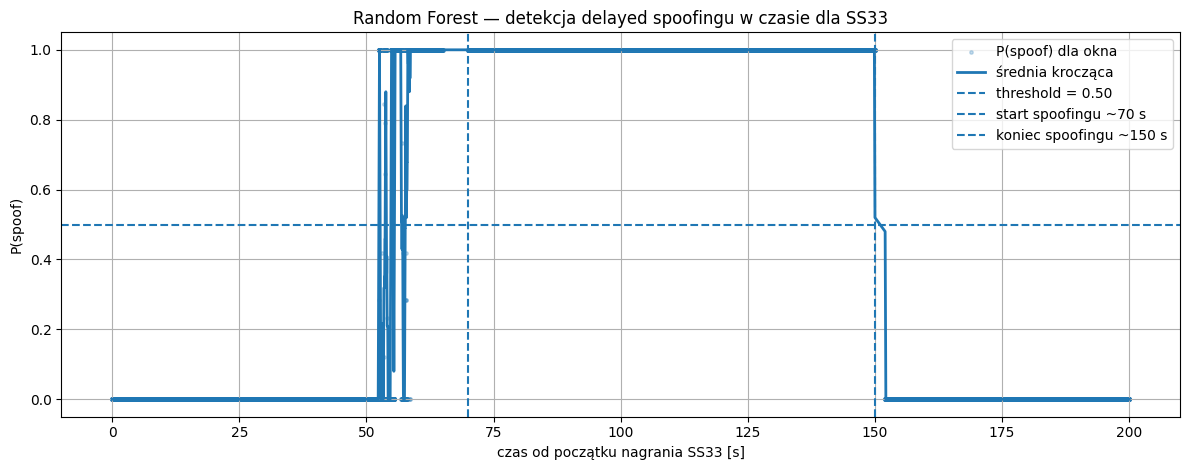

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Używamy progu RF, jeśli był dobrany. Jeśli nie, bierzemy 0.5.
rf_threshold = RF_BEST_THRESHOLD if "RF_BEST_THRESHOLD" in globals() else 0.5

rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
rf_test_pred = (rf_test_proba >= rf_threshold).astype(int)

rf_time_df = test_df.copy().reset_index(drop=True)
rf_time_df["y_true"] = np.array(y_test)
rf_time_df["y_proba"] = rf_test_proba
rf_time_df["y_pred"] = rf_test_pred

# Sortujemy po czasie.
rf_time_df = rf_time_df.sort_values("window_start_s").copy()

# Wygładzenie tylko do wizualizacji.
rf_time_df["p_spoof_smooth"] = (
    rf_time_df["y_proba"]
    .rolling(25, center=True, min_periods=1)
    .mean()
)

plt.figure(figsize=(12, 4.8))

plt.scatter(
    rf_time_df["window_start_s"],
    rf_time_df["y_proba"],
    s=6,
    alpha=0.25,
    label="P(spoof) dla okna",
)

plt.plot(
    rf_time_df["window_start_s"],
    rf_time_df["p_spoof_smooth"],
    linewidth=2,
    label="średnia krocząca",
)

plt.axhline(
    rf_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"threshold = {rf_threshold:.2f}",
)

plt.axvline(70, linestyle="--", linewidth=1.5, label="start spoofingu ~70 s")
plt.axvline(150, linestyle="--", linewidth=1.5, label="koniec spoofingu ~150 s")

plt.xlabel("czas od początku nagrania SS33 [s]")
plt.ylabel("P(spoof)")
plt.title("Random Forest — detekcja delayed spoofingu w czasie dla SS33")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend(loc="best")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "rf_ss33_detection_over_time.png", dpi=250)
plt.show()

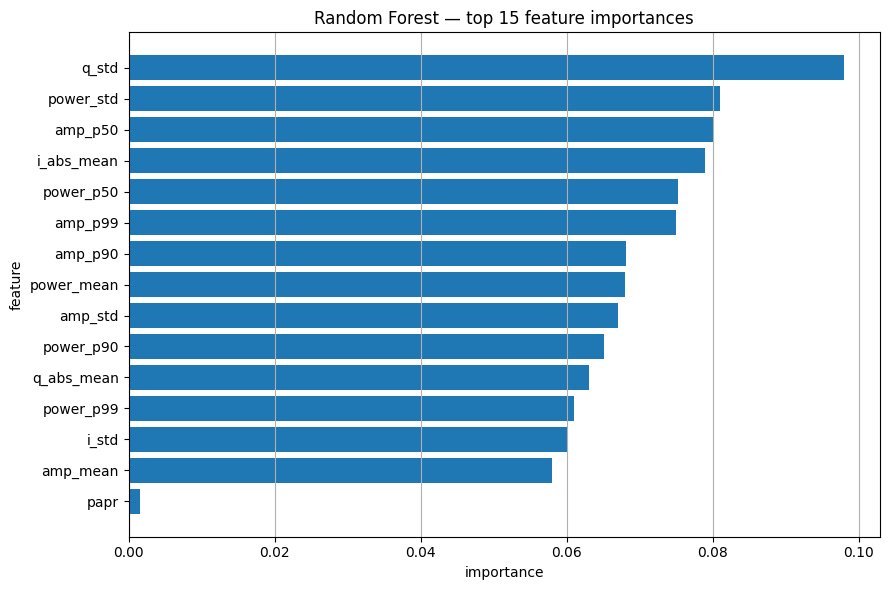

,feature,importance
4,q_std,9.800000e-02
9,power_std,8.100000e-02
19,amp_p50,8.000000e-02
5,i_abs_mean,7.900000e-02
12,power_p50,7.516914e-02
21,amp_p99,7.500000e-02
20,amp_p90,6.817677e-02
8,power_mean,6.800000e-02
16,amp_std,6.700000e-02
13,power_p90,6.506692e-02


In [31]:
import matplotlib.pyplot as plt
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

top_n = 15
top_importance = importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(9, 6))

plt.barh(
    top_importance["feature"],
    top_importance["importance"],
)

plt.xlabel("importance")
plt.ylabel("feature")
plt.title(f"Random Forest — top {top_n} feature importances")
plt.grid(True, axis="x")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "rf_feature_importance_top15.png", dpi=250)
plt.show()

display(importance_df.head(20))

In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, average_precision_score
import joblib
import json
import numpy as np
import pandas as pd

EXPERIMENT_NAME = "random_forest_tuni2025_iq_features"

rf_threshold = RF_BEST_THRESHOLD if "RF_BEST_THRESHOLD" in globals() else 0.5

rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
rf_test_pred = (rf_test_proba >= rf_threshold).astype(int)

cm = confusion_matrix(y_test, rf_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

rf_metrics = {
    "model": "Random Forest",
    "input": "cechy I/Q",
    "threshold": float(rf_threshold),
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),
    "accuracy": float(accuracy_score(y_test, rf_test_pred)),
    "FPR": float(fp / (fp + tn)),
    "FNR": float(fn / (fn + tp)),
    "spoof_recall": float(tp / (tp + fn)),
    "spoof_precision": float(tp / (tp + fp)),
    "ROC_AUC": float(roc_auc_score(y_test, rf_test_proba)),
    "PR_AUC": float(average_precision_score(y_test, rf_test_proba)),
}

# Model
joblib.dump(rf_model, MODELS_DIR / f"{EXPERIMENT_NAME}.joblib")

# Kolejność cech
with open(REPORTS_DIR / f"{EXPERIMENT_NAME}_feature_columns.json", "w") as f:
    json.dump(list(X_train.columns), f, indent=2)

# Threshold + metryki
with open(REPORTS_DIR / f"{EXPERIMENT_NAME}_metrics.json", "w") as f:
    json.dump(rf_metrics, f, indent=2)

# Predykcje testowe
rf_predictions_df = pd.DataFrame({
    "y_true": np.array(y_test),
    "y_proba": rf_test_proba,
    "y_pred": rf_test_pred,
})

if "test_df" in globals():
    for col in ["source_file", "scenario", "window_start_s", "window_end_s"]:
        if col in test_df.columns:
            rf_predictions_df[col] = test_df.reset_index(drop=True)[col]

rf_predictions_df.to_csv(
    REPORTS_DIR / f"{EXPERIMENT_NAME}_test_predictions.csv",
    index=False,
)

# Feature importance
rf_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

rf_importance_df.to_csv(
    REPORTS_DIR / f"{EXPERIMENT_NAME}_feature_importance.csv",
    index=False,
)

print("Saved Random Forest artifacts.")

Saved Random Forest artifacts.
